___

<a href='https://oxiane-institut.com/'> <img src='../oxiane.jpg' /></a>
___

Finance Data Project

In this data project, we will focus on exploratory data analysis of stock prices. Keep in mind that this project is simply meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

Retrieving the Data

In this section, we will learn how to use pandas to directly read data from Google Finance using pandas!

We first need to start with the appropriate imports, which we have already presented for you here.

*Note: [You will need to install pandas-datareader for this to work!](https://github.com/pydata/pandas-datareader) Pandas datareader allows you to [read stock information directly from the Internet](http://pandas.pydata.org/pandas-docs/stable/remote_data.html) Use these links to get installation advice (**pip install pandas-datareader**), or simply follow the video lecture.*

### The imports

Already filled in for you.

In [29]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt



%matplotlib inline

## Data

We need to get data using yfinance. We will obtain stock information for the following banks:

* Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo

**Figure out how to get the stock data from January 1st 2006 to January 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**
1. Use datetime to set start and end datetime objects.
2. Figure out the ticker symbol for each bank.
2. Figure out how to use DataReader to grab info on the stock.

**Use [this documentation page](https://pypi.org/project/yfinance/) for hints and instructions (for example:**)

    import yfinance as yf

    start = "2006-01-01"
    end = "2016-01-01"
    
    # Bank of America
    BAC = yf.download("BAC", start=start, end=end)

------------


In [30]:
start = "2006-01-01"
end = "2016-01-01"

BAC = yf.download("BAC", start=start, end=end)
C = yf.download("C", start=start, end=end)
GS = yf.download("GS", start=start, end=end)
JPM = yf.download("JPM", start=start, end=end)
MS = yf.download("MS", start=start, end=end)
WFC = yf.download("WFC", start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Adj Close: [Adjusted close is the closing price after adjustments for all applicable splits and dividend distributions.](http://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,applicable%20splits%20and%20dividend%20distributions.)


In [31]:
BAC

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2006-01-03,46.919998,47.180000,46.150002,47.080002,31.544888,16296700
2006-01-04,47.000000,47.240002,46.450001,46.580002,31.209892,17757900
2006-01-05,46.580002,46.830002,46.320000,46.639999,31.250101,14970700
2006-01-06,46.799999,46.910000,46.349998,46.570000,31.203194,12599800
2006-01-09,46.720001,46.970001,46.360001,46.599998,31.223293,15619400
...,...,...,...,...,...,...
2015-12-24,17.320000,17.379999,17.219999,17.270000,14.271375,29369400
2015-12-28,17.219999,17.230000,16.980000,17.129999,14.155679,41777500
2015-12-29,17.250000,17.350000,17.160000,17.280001,14.279633,45670400


Create a list of stock ticker symbols (as strings) in alphabetical order. Call this list: tickers

In [32]:
tickers = ["BAC", "C", "GS", "JPM", "MS", "WFC"]

Use pd.concat to concatenate the bank dataframes into a single dataframe called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to which axis you are concatenating on.

In [33]:
bank_stocks = pd.concat([BAC, C, GS, JPM, MS, WFC], axis=1, keys=tickers)
bank_stocks.head()

BAC                                                        \
                 Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2006-01-03  46.919998  47.180000  46.150002  47.080002  31.544888  16296700   
2006-01-04  47.000000  47.240002  46.450001  46.580002  31.209892  17757900   
2006-01-05  46.580002  46.830002  46.320000  46.639999  31.250101  14970700   
2006-01-06  46.799999  46.910000  46.349998  46.570000  31.203194  12599800   
2006-01-09  46.720001  46.970001  46.360001  46.599998  31.223293  15619400   

                     C                                      ...         MS  \
                  Open        High         Low       Close  ...        Low   
Date                                                        ...              
2006-01-03  490.000000  493.799988  481.100006  492.899994  ...  56.740002   
2006-01-04  488.600006  491.000000  483.500000  483.799988  ...  58.349998   
2006-01-05  484.399994  487.799988  484.000000  486.200012  ...  58.020000   
2006-01-06  488.799988  489.000000  482.000000  486.200012  ...  58.049999   
2006-01-09  486.000000  487.399994  483.000000  483.899994  ...  58.619999   

                                                 WFC                        \
                Close  Adj Close   Volume       Open       High        Low   
Date                                                                         
2006-01-03  58.310001  32.661316  5377000  31.600000  31.975000  31.195000   
2006-01-04  58.349998  32.683704  7977800  31.799999  31.820000  31.365000   
2006-01-05  58.509998  32.773338  5778000  31.500000  31.555000  31.309999   
2006-01-06  58.570000  32.806946  6889800  31.580000  31.775000  31.385000   
2006-01-09  59.189999  33.154232  4144500  31.674999  31.825001  31.555000   

                                            
                Close  Adj Close    Volume  
Date                                        
2006-01-03  31.900000  18.979549  11016400  
2006-01-04  31.530001  18.759417  10870000  
2006-01-05  31.495001  18.738588  10158000  
2006-01-06  31.680000  18.848660   8403800  
2006-01-09  31.674999  18.845680   5619600  

[5 rows x 36 columns]

Set the column name levels (this is filled in for you):

In [34]:
bank_stocks.columns.names = ['Bank Ticker','Stock Info']

Check the head of the bank_stocks dataframe.

In [35]:
bank_stocks.head()

Bank Ticker        BAC                                                        \
Stock Info        Open       High        Low      Close  Adj Close    Volume   
Date                                                                           
2006-01-03   46.919998  47.180000  46.150002  47.080002  31.544888  16296700   
2006-01-04   47.000000  47.240002  46.450001  46.580002  31.209892  17757900   
2006-01-05   46.580002  46.830002  46.320000  46.639999  31.250101  14970700   
2006-01-06   46.799999  46.910000  46.349998  46.570000  31.203194  12599800   
2006-01-09   46.720001  46.970001  46.360001  46.599998  31.223293  15619400   

Bank Ticker           C                                      ...         MS  \
Stock Info         Open        High         Low       Close  ...        Low   
Date                                                         ...              
2006-01-03   490.000000  493.799988  481.100006  492.899994  ...  56.740002   
2006-01-04   488.600006  491.000000  483.500000  483.799988  ...  58.349998   
2006-01-05   484.399994  487.799988  484.000000  486.200012  ...  58.020000   
2006-01-06   488.799988  489.000000  482.000000  486.200012  ...  58.049999   
2006-01-09   486.000000  487.399994  483.000000  483.899994  ...  58.619999   

Bank Ticker                                       WFC                        \
Stock Info       Close  Adj Close   Volume       Open       High        Low   
Date                                                                          
2006-01-03   58.310001  32.661316  5377000  31.600000  31.975000  31.195000   
2006-01-04   58.349998  32.683704  7977800  31.799999  31.820000  31.365000   
2006-01-05   58.509998  32.773338  5778000  31.500000  31.555000  31.309999   
2006-01-06   58.570000  32.806946  6889800  31.580000  31.775000  31.385000   
2006-01-09   59.189999  33.154232  4144500  31.674999  31.825001  31.555000   

Bank Ticker                                  
Stock Info       Close  Adj Close    Volume  
Date                                         
2006-01-03   31.900000  18.979549  11016400  
2006-01-04   31.530001  18.759417  10870000  
2006-01-05   31.495001  18.738588  10158000  
2006-01-06   31.680000  18.848660   8403800  
2006-01-09   31.674999  18.845680   5619600  

[5 rows x 36 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check the documentation on [multi-level indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Refer to the solutions if you're not sure how to use .xs(), as this will be a major part of this project.

**What is the maximum closing price for each bank's stock throughout the period?**

In [36]:
bank_stocks.xs(key='Close', axis=1, level='Stock Info').max()

Bank Ticker
BAC     54.900002
C      564.099976
GS     247.919998
JPM     70.080002
MS      89.300003
WFC     58.520000
dtype: float64

Create a new empty DataFrame called returns. This DataFrame will contain the returns of each bank's stock. Returns are typically defined as:

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [37]:
returns = pd.DataFrame()


We can use the pandas `pct_change()` method on the Close column to create a column representing this return value. Create a for loop that iterates through each Bank Stock Ticker, creates this returns column, and sets it as a column in the returns DataFrame.

In [38]:
for ticker in tickers:
    returns[ticker + " Return"] = bank_stocks[ticker]["Close"].pct_change()

returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018462,-0.013812,-0.014183,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000644,-0.004731,0.012030,0.016242,0.010586,-0.000158


Create a pairplot using Seaborn of the returns dataframe. Which stock stands out to you? Can you understand why?

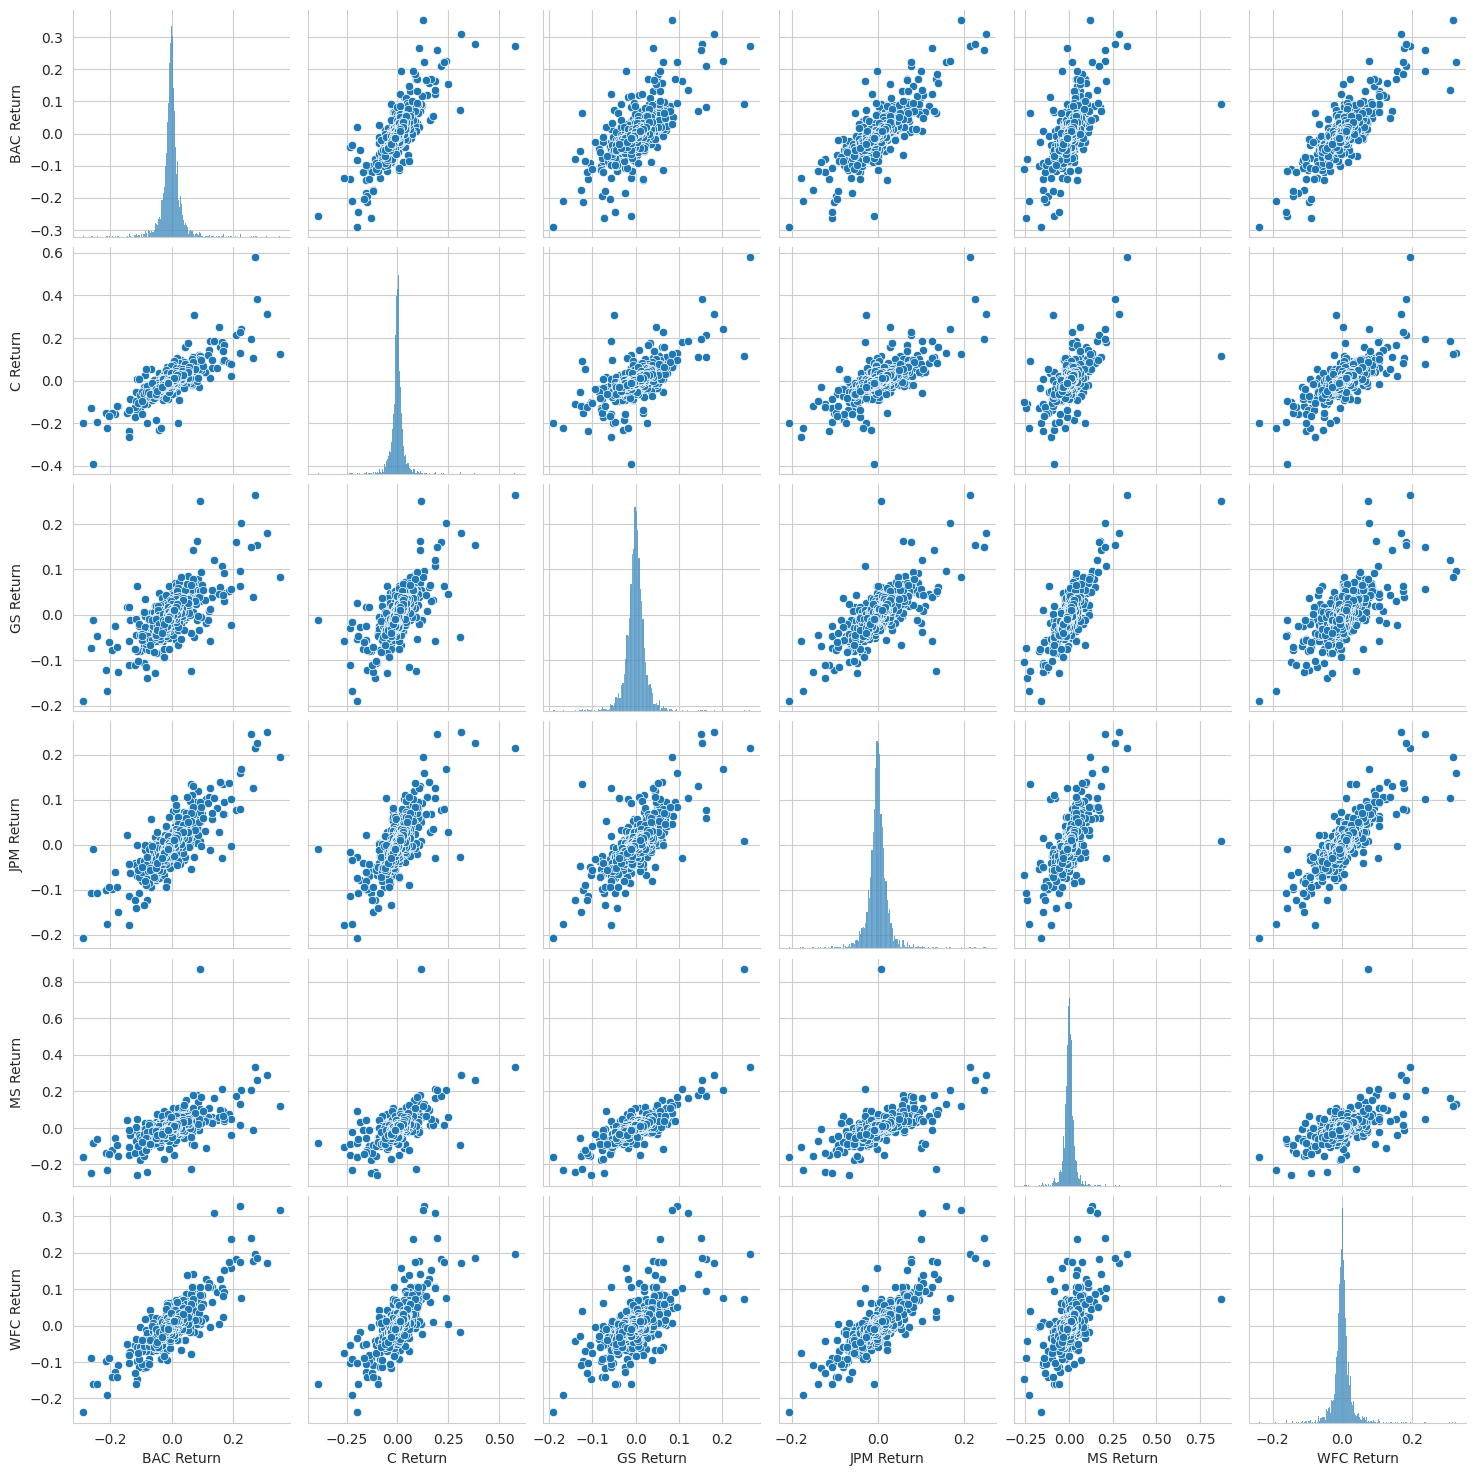

In [39]:
sns.pairplot(returns)

Using this returns DataFrame, determine on which dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did something significant happen that day?

In [40]:
bank_stocks.xs(key='Close', axis=1, level='Stock Info').idxmax()

Bank Ticker
BAC   2006-11-16
C     2006-12-27
GS    2007-10-31
JPM   2015-07-22
MS    2007-06-14
WFC   2015-07-22
dtype: datetime64[ns]

In [41]:
bank_stocks.xs(key="Close", axis=1, level="Stock Info").idxmin()

Bank Ticker
BAC   2009-03-06
C     2009-03-05
GS    2008-11-20
JPM   2009-03-09
MS    2008-11-20
WFC   2009-03-05
dtype: datetime64[ns]

You should have noticed that Citigroup's largest drop and biggest gain were very close together. Did something significant happen during this period?

In [42]:
# In early 2009, Citigroup faced severe financial difficulties 
# due to the global financial crisis. 

# The crisis referred to was the global financial crisis of 2007-2008, 
# also known as the subprime mortgage crisis or the Great Recession.


Take a look at the standard deviation of returns. Which stock would you classify as the riskiest over the entire period? In your opinion, which one would be the riskiest for the year 2015?

In [43]:
returns.std().sort_values(ascending=False)

C Return      0.038672
MS Return     0.037819
BAC Return    0.036647
WFC Return    0.030238
JPM Return    0.027667
GS Return     0.025390
dtype: float64

In [44]:
returns.loc["2015-01-01":"2015-12-31"].std().sort_values(ascending=False)

MS Return     0.016249
BAC Return    0.016163
C Return      0.015289
GS Return     0.014046
JPM Return    0.014017
WFC Return    0.012591
dtype: float64

Create a distribution plot using Seaborn of the 2015 returns for Morgan Stanley

Text(0.5, 1.0, 'Distribution of Morgan Stanley Returns in 2015')

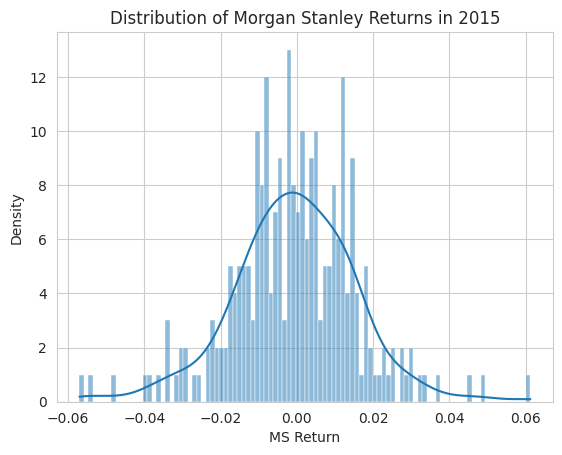

In [45]:
sns.histplot(data=returns.loc["2015-01-01":"2015-12-31"]["MS Return"], bins=100, kde=True)
plt.xlabel('MS Return')
plt.ylabel('Density')
plt.title('Distribution of Morgan Stanley Returns in 2015')

Create a distribution plot using Seaborn of the 2008 returns for CitiGroup

Text(0.5, 1.0, 'Distribution of CitiGroup Returns in 2008')

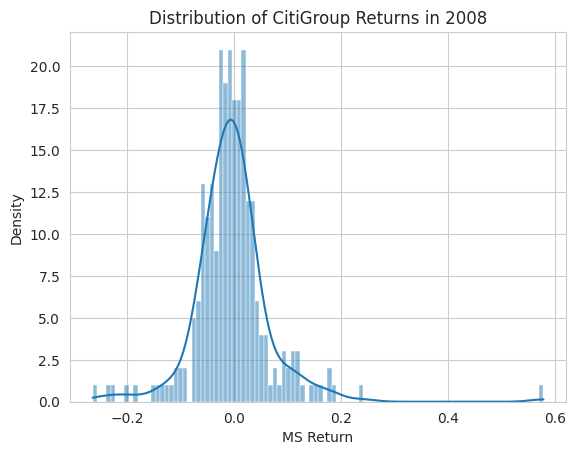

In [46]:
sns.histplot(
    data=returns.loc["2008-01-01":"2008-12-31"]["C Return"], bins=100, kde=True
)
plt.xlabel("MS Return")
plt.ylabel("Density")
plt.title("Distribution of CitiGroup Returns in 2008")

____

More Visualization

A large part of this project will focus on visualizations. Feel free to use any of your favorite visualization libraries to try to recreate the plots described below, such as seaborn, matplotlib, plotly and cufflinks, or simply pandas.

### Imports

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

Create a line plot showing the closing price for each bank for the entire time index. (Hint: Try using a for loop or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)

<Axes: xlabel='Date'>

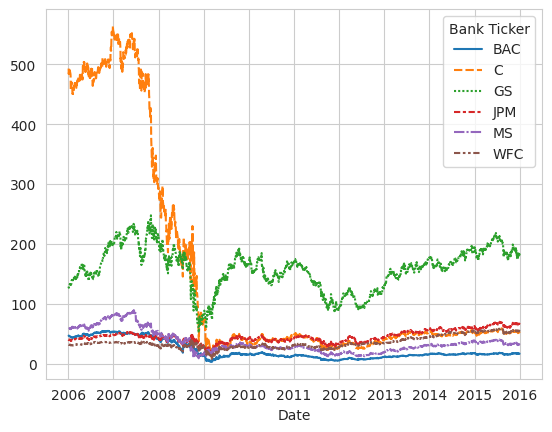

In [48]:
sns.lineplot(data=bank_stocks.xs(key='Close', axis=1, level='Stock Info'))

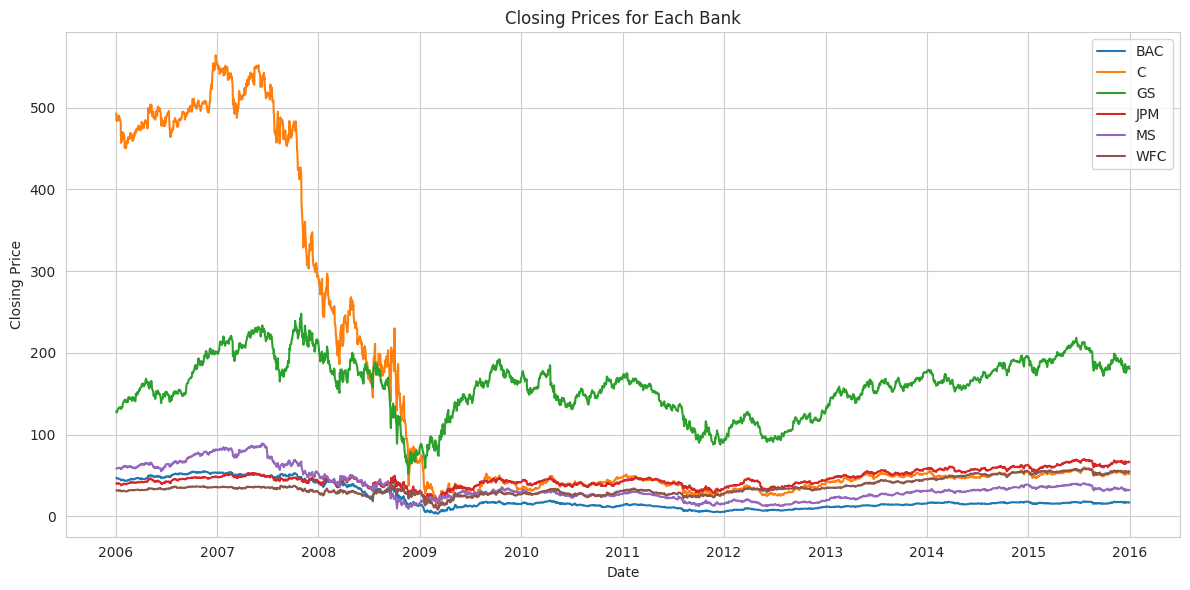

In [49]:
# Doing it with a loop:
plt.figure(figsize=(12, 6))
for bank in bank_stocks.columns.levels[0]:
    plt.plot(bank_stocks.index, bank_stocks[bank]['Close'], label=bank)

plt.title('Closing Prices for Each Bank')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.tight_layout()
plt.show()


## Moving Averages

Let's analyze the moving averages of these stocks in 2008.

**Plot the 30-day moving average against the closing price of Bank of America stock for the year 2008**

In [50]:
BAC_Close = bank_stocks.xs(key="Close", axis=1, level="Stock Info").loc["2008-01-01":"2008-12-31"]["BAC"]

BAC_Close.head()


Date
2008-01-02    40.560001
2008-01-03    40.299999
2008-01-04    39.849998
2008-01-07    39.900002
2008-01-08    38.410000
Name: BAC, dtype: float64

In [51]:
BAC_rolling = BAC_Close.rolling(window=30).mean()
BAC_rolling.head()

Date
2008-01-02   NaN
2008-01-03   NaN
2008-01-04   NaN
2008-01-07   NaN
2008-01-08   NaN
Name: BAC, dtype: float64

<Axes: xlabel='Date', ylabel='BAC'>

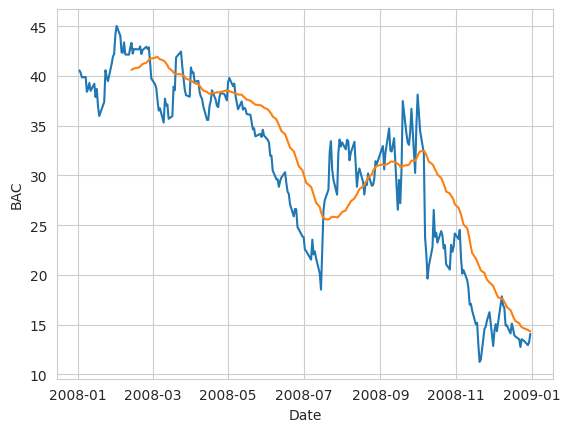

In [52]:
sns.lineplot(data=BAC_Close)
sns.lineplot(data=BAC_rolling)

**Create a heatmap of the correlation between the stocks' closing prices.**

<Axes: xlabel='Bank Ticker', ylabel='Bank Ticker'>

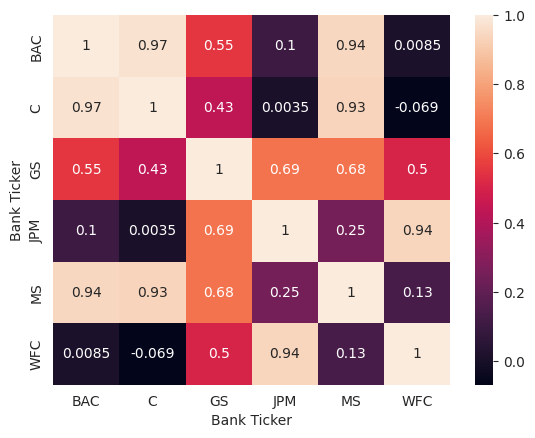

In [53]:
sns.heatmap(bank_stocks.xs(key="Close", axis=1, level="Stock Info").corr(), annot=True)

**Optional: Use Seaborn's clustermap to cluster the correlations:**

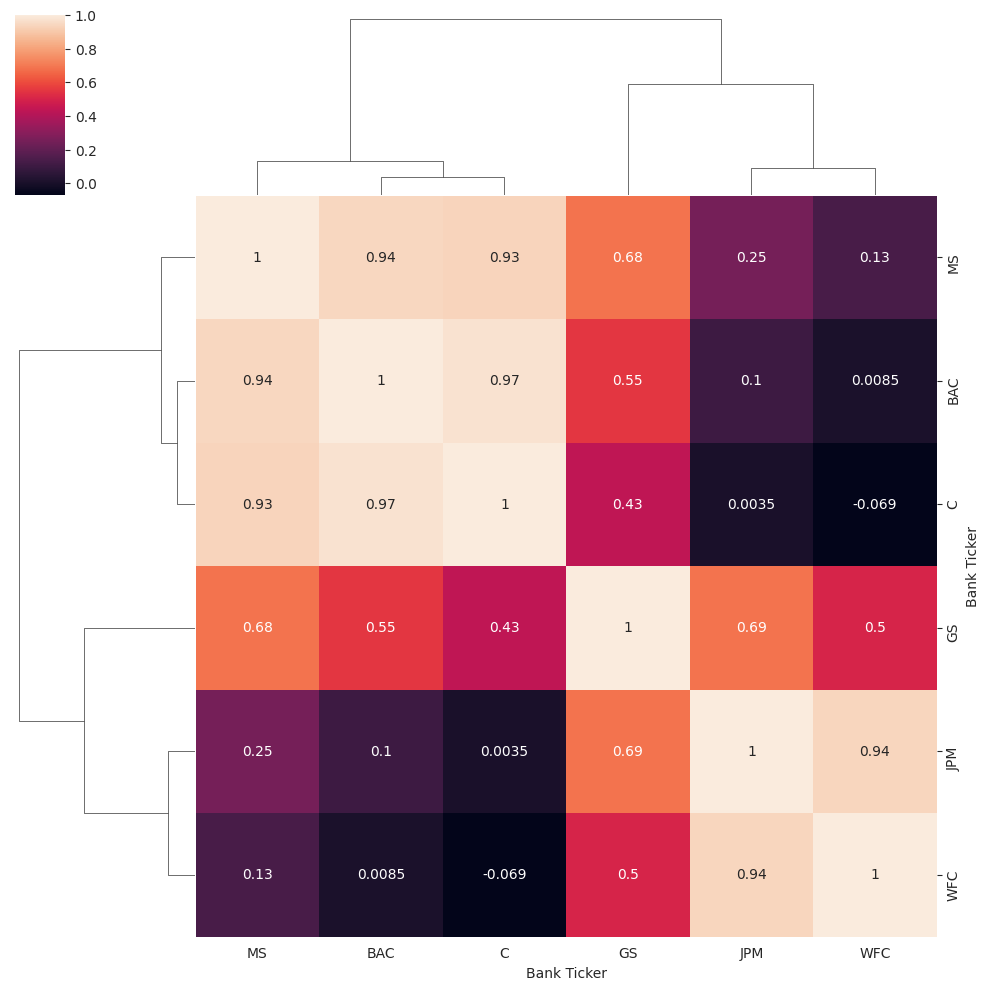

In [54]:
sns.clustermap(bank_stocks.xs(key="Close", axis=1, level="Stock Info").corr(), annot=True)